In [ ]:
# Localiza la raíz del repositorio subiendo desde donde se ejecute el notebook,
# para no depender de una ruta fija de una máquina concreta.
from pathlib import Path

PROJECT_DIR = Path.cwd().resolve()
while not ((PROJECT_DIR / "data").exists() and (PROJECT_DIR / "notebooks").exists()):
    PROJECT_DIR = PROJECT_DIR.parent

# 1. Importación

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(f"{PROJECT_DIR}/data/processed/madrid/listings_full_clean.csv")
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,picture_url,host_id,host_url,...,review_scores_communication,review_scores_location,review_scores_value,license,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,has_license
0,1008521039996399925,https://www.airbnb.com/rooms/1008521039996399925,20260620164952,2026-06-20,city scrape,Alojamiento tranquilo,You'll be in a family and quiet atmosphere.,https://a0.muscache.com/pictures/miso/Hosting-...,509530871,https://www.airbnb.com/users/show/509530871,...,NaN,NaN,NaN,Sin licencia,1,0,1,0,0.00,False
1,887679074200493161,https://www.airbnb.com/rooms/887679074200493161,20260620164952,2026-06-20,city scrape,Hermoso para disfrutar Madrid,Enjoy the simplicity of this quiet and central...,https://a0.muscache.com/pictures/miso/Hosting-...,425181129,https://www.airbnb.com/users/show/425181129,...,5.00,5.00,5.00,Sin licencia,1,1,0,0,0.03,False
2,1105588896774828156,https://www.airbnb.com/rooms/1105588896774828156,20260620164952,2026-07-01,city scrape,Apartamento en Plaza de Chamberí,SEASONAL RENTAL<br /><br />Minimum stay of one...,https://a0.muscache.com/pictures/miso/Hosting-...,564780740,https://www.airbnb.com/users/show/564780740,...,NaN,NaN,NaN,Sin licencia,1,1,0,0,0.00,False
3,1430914078433228549,https://www.airbnb.com/rooms/1430914078433228549,20260620164952,2026-07-01,city scrape,Piso de lujo en el centro,"This special place is close to everything, mak...",https://a0.muscache.com/pictures/hosting/Hosti...,280080724,https://www.airbnb.com/users/show/280080724,...,4.69,4.92,4.15,Sin licencia,2,1,1,0,1.27,False
4,1564834176401698619,https://www.airbnb.com/rooms/1564834176401698619,20260620164952,2026-07-01,previous scrape,"Vecino al Palacio Real, Madrid","Unbeatable location, tourist areas.",https://a0.muscache.com/pictures/hosting/Hosti...,554492742,https://www.airbnb.com/users/show/554492742,...,5.00,5.00,4.00,Spain - National registration number<br />Exem...,1,1,0,0,0.17,True


## 2. Selección de variables de partida

Se descartan los mismos seis grupos de columnas que en Barcelona, comprobando primero que los motivos siguen siendo válidos con datos de Madrid:

#### ¿Por qué se descarta `price_quote_*`?

In [3]:
(df["price"] == df["price_quote_price_per_night"]).mean()

np.float64(1.0)

100% igual que en Barcelona: `price_quote_price_per_night` es literalmente `price`, no aporta nada nuevo.

#### ¿Por qué se descarta `estimated_revenue_l365d`?

In [4]:
(df["price"] * df["estimated_occupancy_l365d"]).corr(df["estimated_revenue_l365d"])

np.float64(0.9999999999791699)

Correlación ~1.00, igual que en Barcelona: es `price × estimated_occupancy_l365d`, una fuga directa de la variable objetivo.

#### ¿Por qué se descartan `name`, `description`, `host_about` y `host_location`?

Mismo motivo que en Barcelona: texto libre sin procesar, que necesitaría NLP para aprovecharse y queda fuera del alcance de este proyecto.

#### Aplicando los descartes

In [5]:
drop_cols = [
    # URLs y metadatos de scraping
    "listing_url", "picture_url", "host_url", "host_profile_url", "host_picture_url",
    "scrape_id", "last_scraped", "source", "calendar_last_scraped",
    # texto libre sin procesar (amenities NO va aquí: se procesa en la sección 9)
    "name", "description", "host_about", "host_location",
    # columnas que ya cumplieron su función
    "bathrooms_text", "license", "host_name", "host_listings_count",
    # price_quote_* (redundante con price)
    "price_quote_checkin_date", "price_quote_checkout_date", "price_quote_total_price",
    "price_quote_price_per_night", "price_quote_raw",
    # familias redundantes de estancia
    "minimum_minimum_nights", "maximum_minimum_nights", "minimum_maximum_nights",
    "maximum_maximum_nights", "minimum_nights_avg_ntm", "maximum_nights_avg_ntm",
    # familia redundante de disponibilidad
    "availability_30", "availability_60", "availability_90", "availability_eoy",
    # ventanas de reviews más finas
    "number_of_reviews_l30d", "number_of_reviews_ly",
    # fuga de información
    "estimated_revenue_l365d",
]

df = df.drop(columns=drop_cols)
df.shape

(18949, 43)

Quedan 43 columnas de partida, exactamente las mismas que en Barcelona (mismo esquema de origen). `id`, `host_id` y `host_profile_id` se mantienen como identificadores. `amenities` se deja para la sección 9. El resto se transforma en las siguientes secciones.

In [6]:
df.columns.tolist()

['id',
 'host_id',
 'host_profile_id',
 'hosts_time_as_user_years',
 'hosts_time_as_user_months',
 'hosts_time_as_host_years',
 'hosts_time_as_host_months',
 'host_is_superhost',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'minimum_nights',
 'maximum_nights',
 'availability_365',
 'number_of_reviews',
 'number_of_reviews_ltm',
 'estimated_occupancy_l365d',
 'first_review',
 'last_review',
 'review_scores_rating',
 'review_scores_accuracy',
 'review_scores_cleanliness',
 'review_scores_checkin',
 'review_scores_communication',
 'review_scores_location',
 'review_scores_value',
 'calculated_host_listings_count',
 'calculated_host_listings_count_entire_homes',
 'calculated_host_listings_count_private_rooms',
 'calculated_host_listings_count_shared_rooms',
 'reviews_per_month',
 'has_lice

## 3. Transformaciones numéricas

### 3.1 Logaritmos

In [7]:
log_vars = [
    "price", "number_of_reviews", "number_of_reviews_ltm", "reviews_per_month",
    "bedrooms", "beds", "bathrooms", "calculated_host_listings_count",
]

for c in log_vars:
    df[f"{c}_log"] = np.log1p(df[c])

Text(0.5, 1.0, 'price_log')

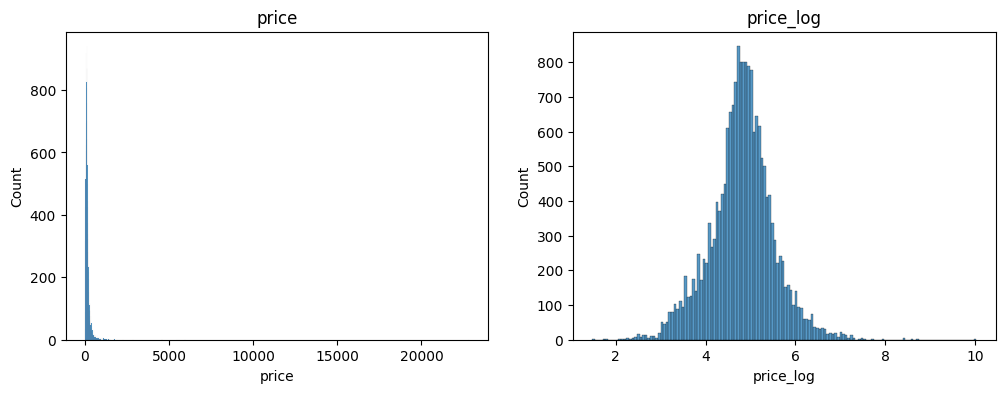

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df, x="price", ax=axes[0])
axes[0].set_title("price")
sns.histplot(df, x="price_log", ax=axes[1])
axes[1].set_title("price_log")

El efecto del logaritmo es todavía más necesario aquí que en Barcelona: la asimetría de `price` en bruto era 38.4 (frente a una asimetría bastante más moderada en Barcelona), así que sin el log un modelo lineal se vería todavía más arrastrado por la cola de precios altos genuinos que ya se vio en `01_eda.ipynb`.

### 3.2 Ratios

In [9]:
df["price_per_accommodate"] = df["price"] / df["accommodates"]
df["price_per_min_night"] = df["price"] / df["minimum_nights"]

df[["price_per_accommodate", "price_per_min_night"]].describe()

,price_per_accommodate,price_per_min_night
count,18949.000000,18949.000000
mean,51.819208,104.434659
std,172.891733,166.053709
min,0.775000,0.015500
25%,30.500000,25.443333
50%,41.750000,69.500000
75%,58.187500,133.000000
max,22832.500000,11416.250000


<Axes: xlabel='price_per_accommodate', ylabel='Count'>

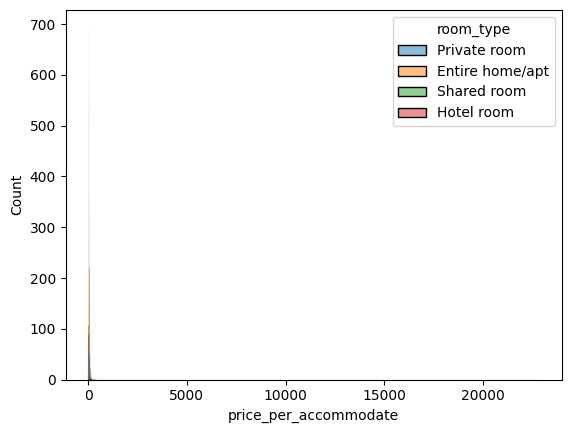

In [10]:
sns.histplot(df, x="price_per_accommodate", hue="room_type")

## 4. Variables de tamaño: multicolinealidad

En la EDA, `accommodates`/`bedrooms`/`beds`/`bathrooms` correlacionan entre 0.32 y 0.64, más moderado que el 0.80-0.84 que se veía en Barcelona. Aun así, se comprueba el VIF con el mismo criterio.

In [11]:
size_vars = ["accommodates", "bedrooms", "beds", "bathrooms"]

corr_matrix = df[size_vars].corr().values
vif = np.diag(np.linalg.inv(corr_matrix))

pd.Series(vif, index=size_vars, name="VIF")

accommodates    1.964052
bedrooms        2.019197
beds            1.732572
bathrooms       1.270451
Name: VIF, dtype: float64

Los cuatro VIF están entre 1.27 y 2.01, **incluso más bajos que en Barcelona** (1.8-4.3), muy lejos del umbral de 5. Aquí no hay ninguna duda: las cuatro variables de tamaño aportan información claramente distinta entre sí. Se mantienen las cuatro tal cual.

## 5. Codificación de categóricas

Mismos cuatro tratamientos que en Barcelona, según cardinalidad: `room_type` y `neighbourhood_group_cleansed` directo a one-hot. `neighbourhood_cleansed` y `property_type` con su propio tratamiento por tener demasiadas categorías.

### 5.1 `room_type`

In [12]:
df = pd.get_dummies(df, columns=["room_type"], prefix="room_type")

### 5.2 `neighbourhood_group_cleansed`

In [13]:
df = pd.get_dummies(df, columns=["neighbourhood_group_cleansed"], prefix="district")

21 columnas de distrito, frente a las 10 de Barcelona, coherente con los 21 distritos reales de Madrid.

### 5.3 `neighbourhood_cleansed`

**Mismo aviso que en Barcelona**: el smoothing de aquí es provisional, calculado sobre todo el dataset (train + test todavía sin dividir). Es fuga de datos tal cual, y se corrige de verdad en `03_model_baseline.ipynb`, recalculando el encoding solo con train. Aquí se deja calculado únicamente para poder seguir explorando el resto del feature engineering.

In [14]:
global_mean_price = df["price"].mean()
neigh_stats = df.groupby("neighbourhood_cleansed")["price"].agg(["mean", "count"])

smoothing = 10
smoothed_mean = (neigh_stats["count"] * neigh_stats["mean"] + smoothing * global_mean_price) / (neigh_stats["count"] + smoothing)

df["neighbourhood_price_encoded"] = df["neighbourhood_cleansed"].map(smoothed_mean)

In [15]:
df[["neighbourhood_cleansed", "neighbourhood_price_encoded"]].drop_duplicates().sort_values("neighbourhood_price_encoded", ascending=False).head(10)

,neighbourhood_cleansed,neighbourhood_price_encoded
74,Recoletos,252.564413
18272,Valdefuentes,250.320432
39,Sol,236.552386
742,Fuentelareina,223.121596
181,Jerónimos,220.826377
124,Castellana,219.262846
14819,San Juan Bautista,217.840123
30,Cortes,209.298574
70,Goya,208.087588
116,Niño Jesús,207.576272


El más caro por precio medio suavizado es `Recoletos` (253€), seguido de `Valdefuentes` (250€) y `Sol` (237€), `Jerónimos`/`Castellana` (219-221€, también corazón de `Salamanca`) completan el grupo de cabeza, coherente con ser las zonas más céntricas y de mayor poder adquisitivo de Madrid. Antes de la limpieza de precios de bloqueo individuales (sección 8.4 de la EDA) el primer puesto lo ocupaba `Arcos` (411€), un barrio pequeño (41 anuncios) donde un único host con 8 anuncios idénticos a 1.892€/noche, sin ninguna reserva ni reseña reciente, disparaba la media incluso con el smoothing. Sin esos 8 anuncios la media de `Arcos` cae de 471€ a un valor normal (mediana 70€) y el barrio deja de aparecer entre los más caros.

### 5.4 `property_type`

In [16]:
property_type_counts = df["property_type"].value_counts()
rare_property_types = property_type_counts[property_type_counts < 30].index

df["property_type_grouped"] = df["property_type"].where(
    ~df["property_type"].isin(rare_property_types), "Other"
)
df["property_type_grouped"].nunique()

20

20 categorías tras agrupar las que tienen menos de 30 apariciones en "Other" (frente a 14 en Barcelona): Madrid tiene más variedad de tipos de propiedad con suficiente muestra propia (por ejemplo `Room in aparthotel` o `Private room in casa particular`, categorías que en Barcelona no llegaban al umbral).

In [17]:
df = pd.get_dummies(df, columns=["property_type_grouped"], prefix="property_type")

Con esto, `room_type`, `neighbourhood_group_cleansed` y `property_type_grouped` quedan como columnas binarias, y `neighbourhood_cleansed` como `neighbourhood_price_encoded`. Mismo tratamiento que en Barcelona en todo.

## 6. Variables derivadas del host

### 6.1 Antigüedad del host

In [18]:
df["host_tenure_years"] = df["hosts_time_as_host_years"] + df["hosts_time_as_host_months"] / 12
df["host_tenure_years"].describe()

count    18949.000000
mean         5.720654
std          3.808695
min          0.000000
25%          2.583333
50%          4.916667
75%          8.916667
max         15.416667
Name: host_tenure_years, dtype: float64

### 6.2 Tamaño del host

In [19]:
for threshold in [1, 2, 5, 10]:
    pct = (df["calculated_host_listings_count"] > threshold).mean() * 100
    print(f"más de {threshold} anuncios: {pct:.1f}%")

más de 1 anuncios: 77.5%
más de 2 anuncios: 67.8%
más de 5 anuncios: 53.7%
más de 10 anuncios: 42.2%


Igual que en Barcelona, un flag binario no serviría: el 77.5% de los anuncios ya supera 1 anuncio por host. Se reutilizan los mismos cortes que en Barcelona (1, 10, 50) para mantener la misma definición de `individual`/`pequeno`/`mediano`/`grande` entre ciudades, en vez de recalcular cuartiles específicos de Madrid: así la variable significa lo mismo se mire desde donde se mire.

In [20]:
bins = [0, 1, 10, 50, df["calculated_host_listings_count"].max()]
labels = ["individual", "pequeno", "mediano", "grande"]
df["host_size_tier"] = pd.cut(df["calculated_host_listings_count"], bins=bins, labels=labels)

df.groupby("host_size_tier", observed=True)["price"].agg(["count", "median"])

,count,median
host_size_tier,,
individual,4255,122.61
pequeno,6699,120.00
mediano,4335,130.00
grande,3660,127.41


**Diferencia real con Barcelona**: allí `mediano` destacaba claramente por encima del resto (no monótono, pero con una diferencia visible). Aquí las cuatro categorías quedan casi empatadas (120-130€ de mediana): el tamaño del portfolio del host apenas se nota en el precio en Madrid. Aun así, se mantiene el one-hot en vez de un valor ordinal, por la misma razón que en Barcelona (no hay una relación monótona clara que un número pueda representar bien).

In [21]:
df = pd.get_dummies(df, columns=["host_size_tier"], prefix="host_size")

### 6.3 Composición del portfolio del host

In [22]:
df["host_entire_homes_ratio"] = (
    df["calculated_host_listings_count_entire_homes"] / df["calculated_host_listings_count"]
)
df["host_entire_homes_ratio"].corr(df["price"])

np.float64(0.17746163118919867)

0.18 de correlación con `price` (más bajo que en Barcelona, 0.23), pero aquí el contraste con la variable de la que deriva es más llamativo: `calculated_host_listings_count` en bruto correlaciona **-0.01** con `price` (prácticamente nada, coherente con la sección 6.2). El ratio no es solo un matiz aquí, es la única de las dos que aporta algo.

## 7. Variables derivadas de reviews

### 7.1 `has_reviews`

In [23]:
df["has_reviews"] = df["number_of_reviews"] > 0
df["has_reviews"].value_counts()

has_reviews
True     16354
False     2595
Name: count, dtype: int64

### 7.2 Antigüedad y recencia de reviews

In [24]:
df["first_review"] = pd.to_datetime(df["first_review"])
df["last_review"] = pd.to_datetime(df["last_review"])

reference_date = df["last_review"].max()
df["listing_age_days"] = (reference_date - df["first_review"]).dt.days
df["days_since_last_review"] = (reference_date - df["last_review"]).dt.days

df[["listing_age_days", "days_since_last_review"]].describe()

,listing_age_days,days_since_last_review
count,16354.000000,16354.000000
mean,1191.910847,135.904672
std,1081.506918,309.533086
min,0.000000,0.000000
25%,391.000000,21.000000
50%,842.500000,30.000000
75%,1593.000000,80.000000
max,5839.000000,4293.000000


Ambas quedan `NaN` para los 2595 anuncios sin reviews, igual que en Barcelona. La correlación con `price` es todavía más débil que en Barcelona (0.04 en `listing_age_days`, 0.04 en `days_since_last_review`, frente a 0.13 y -0.07 allí): en Madrid, cuánto lleva publicado o cuándo fue la última reseña casi no dice nada del precio. Se mantienen de todos modos, coherente con el criterio de la EDA de no descartar por una correlación débil.

### 7.3 Los 6 subscores de review

In [25]:
df = df.drop(columns=[
    "review_scores_accuracy", "review_scores_cleanliness", "review_scores_checkin",
    "review_scores_communication", "review_scores_location", "review_scores_value",
])

Mismo motivo que en Barcelona: son variables muy correlacionadas entre sí y con `review_scores_rating`, que ya se vio en la EDA que apenas se relaciona con `price`.

## 8. Variables geográficas

### 8.1 Distancia al centro

El punto de referencia cambia respecto a Barcelona: en vez de Plaça Catalunya, se usa **Puerta del Sol** (Kilómetro Cero), el centro geográfico y simbólico de Madrid.

In [26]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # radio de la Tierra en km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

center_lat, center_lon = 40.4168, -3.7038  # Puerta del Sol
df["distance_to_center_km"] = haversine(df["latitude"], df["longitude"], center_lat, center_lon)

df["distance_to_center_km"].describe()

count    18949.000000
mean         2.709864
std          2.468981
min          0.006050
25%          0.771850
50%          1.892592
75%          3.998281
max         14.496807
Name: distance_to_center_km, dtype: float64

In [27]:
df["distance_to_center_km"].corr(df["price"]), df["distance_to_center_km"].corr(df["neighbourhood_price_encoded"]), df["distance_to_center_km"].corr(np.log1p(df["price"]))

(np.float64(-0.10118084182560214),
 np.float64(-0.5555520817316404),
 np.float64(-0.21016575214379146))

Con precio en bruto la correlación es débil (-0.10), y con `log(price)` sube a -0.21: el mismo artefacto de escala que ya se documentó en la EDA. La correlación con `neighbourhood_price_encoded` (-0.56) es bastante más fuerte que en Barcelona (-0.43), coherente con la mayor concentración geográfica de Madrid (`Centro` con el 42% de la oferta): relacionada con el barrio, pero no redundante.

Text(0, 0.5, 'log1p(price)')

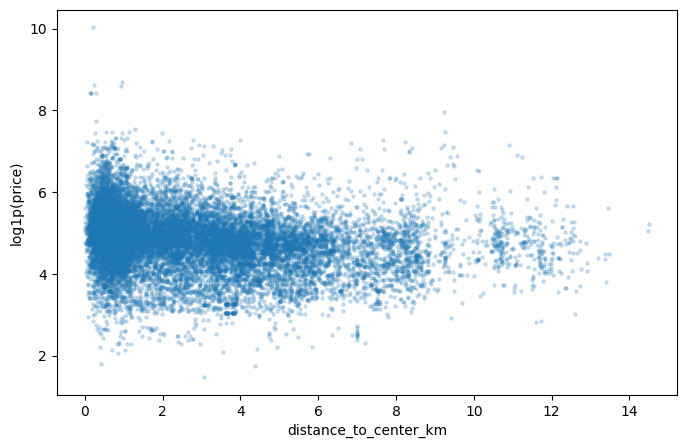

In [28]:
plt.figure(figsize=(8, 5))
plt.scatter(df["distance_to_center_km"], np.log1p(df["price"]), s=5, alpha=0.2)
plt.xlabel("distance_to_center_km")
plt.ylabel("log1p(price)")

### 8.2 Densidad de anuncios cercanos

In [29]:
from sklearn.neighbors import BallTree

coords_rad = np.radians(df[["latitude", "longitude"]].to_numpy())
tree = BallTree(coords_rad, metric="haversine")
EARTH_R_KM = 6371
radius_m = 150
counts = tree.query_radius(coords_rad, r=(radius_m / 1000) / EARTH_R_KM, count_only=True)
df["n_nearby_150m"] = counts - 1  # excluir el propio anuncio

df["n_nearby_150m"].describe()

count    18949.000000
mean        84.453533
std         87.468481
min          0.000000
25%         13.000000
50%         36.000000
75%        168.000000
max        314.000000
Name: n_nearby_150m, dtype: float64

Mismo resultado que en la EDA (media ~84, mediana 36): bastante más alto que Barcelona (~55 de media), coherente con la fuerte concentración de anuncios en `Centro`. Se mantiene como candidata, igual que en Barcelona.

## 9. Amenities

### 9.1 Parsear y construir los flags

In [30]:
import ast

amenities_parsed = df["amenities"].apply(ast.literal_eval)

def has_any(lst, keywords, exclude=None):
    for item in lst:
        low = item.lower()
        if exclude and any(ex in low for ex in exclude):
            continue
        if any(kw in low for kw in keywords):
            return True
    return False

df["has_ac"] = amenities_parsed.apply(lambda l: has_any(l, ["air condition", "ac - "]))
df["has_pool"] = amenities_parsed.apply(lambda l: has_any(l, ["pool"], exclude=["pool table"]))
df["has_dishwasher"] = amenities_parsed.apply(lambda l: has_any(l, ["dishwasher"]))
df["n_amenities"] = amenities_parsed.apply(len)

df[["has_ac", "has_pool", "has_dishwasher", "n_amenities"]].describe()

,n_amenities
count,18949.000000
mean,28.090189
std,12.764795
min,0.000000
25%,19.000000
50%,29.000000
75%,36.000000
max,96.000000


Prevalencias consistentes con la EDA (`has_ac` 80.3%, `has_dishwasher` 41.3%, `has_pool` 4.3%, `n_amenities` media 28.1), muy parecidas a Barcelona. La diferencia real ya se documentó en `01_eda.ipynb`: estas cuatro variables correlacionan más con `log(price)` en Madrid que en Barcelona (`has_ac` 0.31 vs 0.14), así que aquí hay motivos para esperar que aporten algo más al modelo final.

### 9.2 Descartar `amenities`

In [31]:
df = df.drop(columns=["amenities"])
df.shape

(18949, 105)

## 10. Dataset final para modelado

### 10.1 Un último cabo suelto: `hosts_time_as_user_*`

In [32]:
df["host_user_tenure_years"] = df["hosts_time_as_user_years"] + df["hosts_time_as_user_months"] / 12

### 10.2 Limpieza final

In [33]:
final_drop = [
    "property_type",
    "hosts_time_as_host_years", "hosts_time_as_host_months",
    "hosts_time_as_user_years", "hosts_time_as_user_months",
    "first_review", "last_review",
    "calculated_host_listings_count_entire_homes",
    "calculated_host_listings_count_private_rooms",
    "calculated_host_listings_count_shared_rooms",
]

df = df.drop(columns=final_drop)
df.shape

(18949, 96)

### 10.3 Comprobación de nulos

In [34]:
null_counts = df.isnull().sum()
null_counts[null_counts > 0]

review_scores_rating      2595
listing_age_days          2595
days_since_last_review    2595
dtype: int64

Los tres coinciden en las mismas 2595 filas (`has_reviews == False`), igual que en Barcelona. No hace falta ninguna acción más.

### 10.4 Identificadores, objetivo y features

In [35]:
id_cols = ["id", "host_id", "host_profile_id"]
target_col = "price"
pending_cols = ["neighbourhood_cleansed"]
feature_cols = [c for c in df.columns if c not in id_cols + [target_col] + pending_cols]

print("identificadores:", len(id_cols))
print("objetivo:", target_col)
print("pendiente de la corrección de fuga (03_model_baseline.ipynb):", len(pending_cols))
print("features:", len(feature_cols))

identificadores: 3
objetivo: price
pendiente de la corrección de fuga (03_model_baseline.ipynb): 1
features: 91


91 features de partida (frente a 74 en Barcelona antes de las 5 nuevas de amenities/densidad, que aquí ya van incluidas desde el principio). La diferencia viene sobre todo de tener más categorías propias tras el one-hot: 21 distritos en vez de 10, y 20 tipos de propiedad en vez de 14.

### 10.5 Exportar

In [36]:
df.to_csv(f"{PROJECT_DIR}/data/processed/madrid/listings_full_features.csv", index=False)